# Explore here

In [6]:
# Your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pickle

df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv')

df.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [7]:
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
ts = df['sales']

print(ts.head())

date
2022-09-03 17:10:08.079328    55.292157
2022-09-04 17:10:08.079328    53.803211
2022-09-05 17:10:08.079328    58.141693
2022-09-06 17:10:08.079328    64.530899
2022-09-07 17:10:08.079328    66.013633
Name: sales, dtype: float64


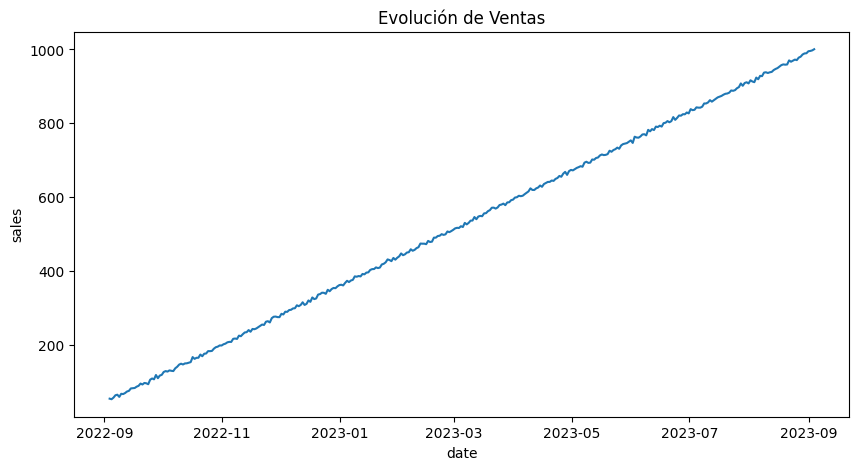

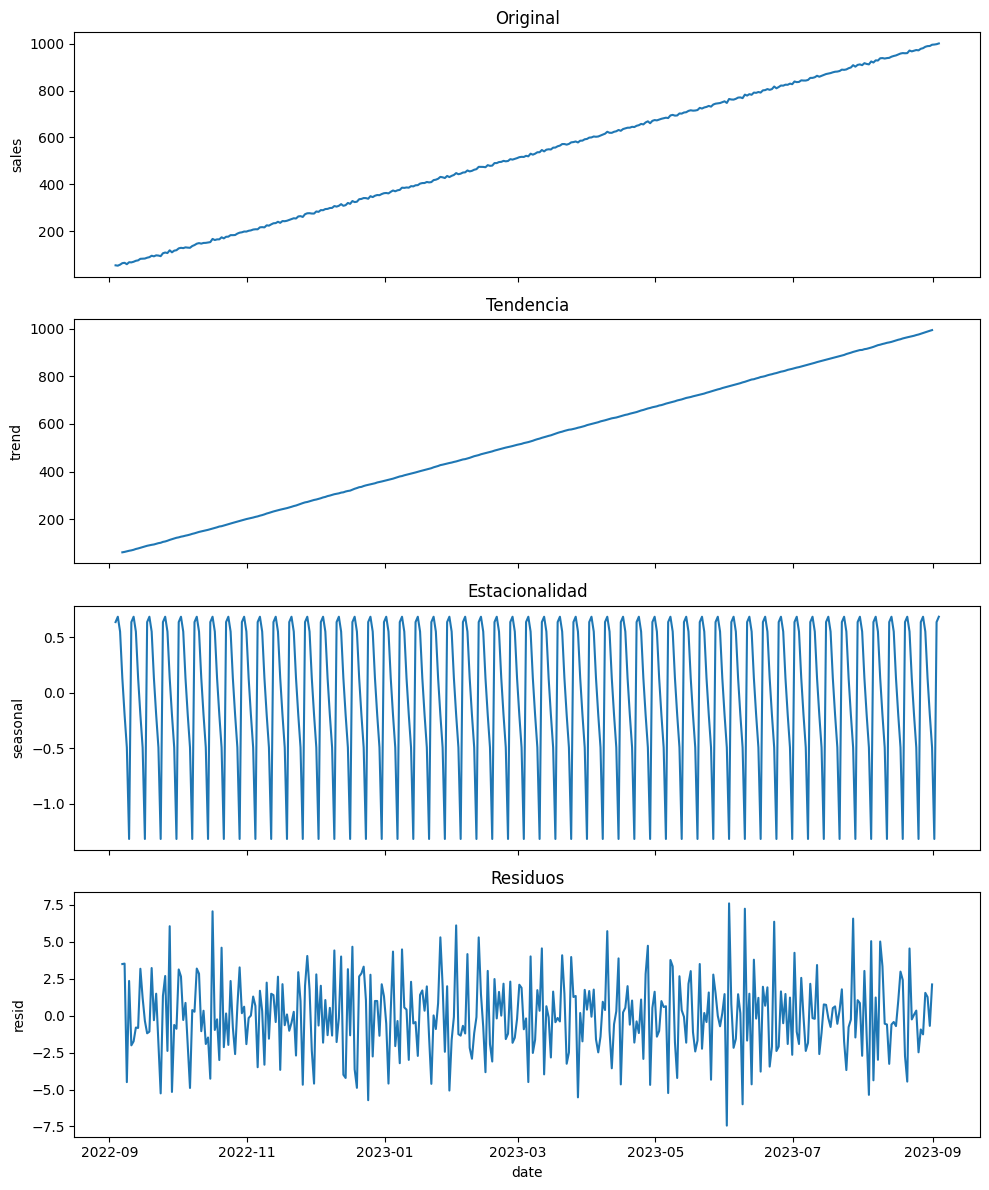

In [8]:
# Visualización inicial
fig, axis = plt.subplots(figsize = (10, 5))
sns.lineplot(data = ts)
plt.title("Evolución de Ventas")
plt.show()

# Descomposición de la serie (periodo estimado de 7 días por ser ventas diarias)
decomposition = seasonal_decompose(ts, period = 7)

# Análisis de componentes
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Gráficos de análisis
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
sns.lineplot(ax=axes[0], data=ts).set_title('Original')
sns.lineplot(ax=axes[1], data=trend).set_title('Tendencia')
sns.lineplot(ax=axes[2], data=seasonal).set_title('Estacionalidad')
sns.lineplot(ax=axes[3], data=residual).set_title('Residuos')
plt.tight_layout()
plt.show()

#Respuestas al análisis:

¿Cuál es el tensor?: El tensor es diario (unidad mínima de tiempo,vemos que hay registros consistentes cada día del mes.

¿Cuál es la tendencia?: Se aprecia una tendencia claramente ascendente, lo que indica crecimiento en las ventas,(positiva)sube desde 100 hasta casi 1000 ventas.

¿Existe variabilidad o presencia de ruido?
Sí, el componente Residual muestra variaciones aleatorias. Esto confirma que hay factores externos que afectan las ventas día a día, es un ruido muy bajo (oscila entre -7.5 y 7.5).

In [10]:
#Confirmar la estacionariedad de la serie con la prueba de Dickey-Fuller
def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    print(dfoutput)

test_stationarity(ts)

Resultados de la prueba de Dickey-Fuller:
Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
dtype: float64


#no es estacionaria porque  p-value es 0.986190 

In [11]:
# División Train/Test (80% entrenamiento, 20% prueba)
train_size = int(len(ts) * 0.8)
train_data, test_data = ts[0:train_size], ts[train_size:]

# Encontrar el mejor ARIMA automáticamente (Igual que en la práctica)
# Usamos m=7 porque detectamos estacionalidad semanal
model = auto_arima(train_data, seasonal = True, m = 7, trace = True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=1477.640, Time=1.03 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=1675.428, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=1574.824, Time=0.11 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=1472.428, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=1763.761, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=1475.165, Time=0.10 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=1472.511, Time=0.61 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=inf, Time=0.75 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=1471.456, Time=0.27 sec
 ARIMA(0,1,1)(2,0,0)[7] intercept   : AIC=1472.463, Time=1.15 sec
 ARIMA(0,1,1)(2,0,1)[7] intercept   : AIC=1470.355, Time=1.04 sec
 ARIMA(0,1,1)(2,0,2)[7] intercept   : AIC=inf, Time=1.25 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=0.98 sec
 ARIMA(0,1,0)(2,0,1)[7] intercept   : AIC=1678.420, Time=0.19 sec
 ARIMA(1,1,1)(2,0,1)[7] intercept   : AIC=1472.8

# Best model es: ARIMA(0,1,1)(2,0,1)[7] intercept.

(0, 1, 1): La parte no estacional. El 1 del medio indica las ventas tienen unan tendencia.
(2, 0, 1)[7]: La parte estacional. El [7] confirma que el modelo detectó que lo que pasó hace dos semanas influye en la predicción de hoy.
Intercept: Significa que hay un valor base constante en tus ventas.

--- Evaluación del Modelo de Ventas ---
Error Absoluto Medio (MAE): 2.1613
Raíz del Error Cuadrático Medio (RMSE): 2.7297


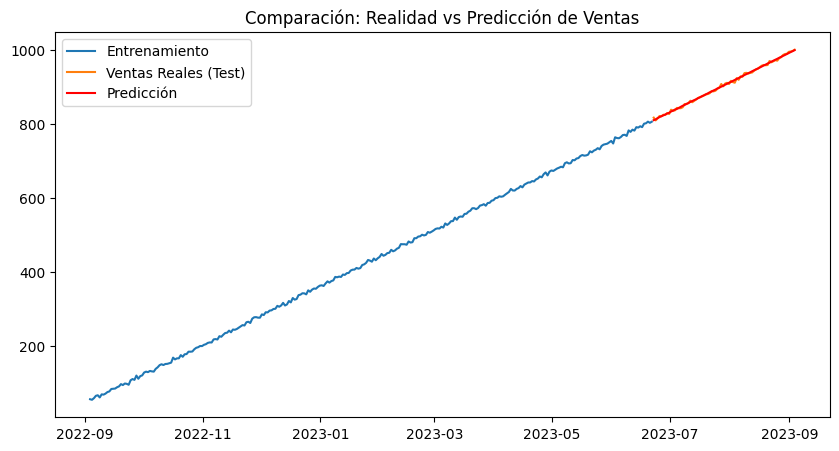

In [12]:
# 1. Generamos la predicción para el futuro (el tamaño de nuestro set de prueba)
forecast = model.predict(n_periods=len(test_data))

# 2. Calculamos el error (MAE y RMSE) para ver qué tan bueno es el modelo
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test_data, forecast)
rmse = np.sqrt(mean_squared_error(test_data, forecast))

print(f"--- Evaluación del Modelo de Ventas ---")
print(f"Error Absoluto Medio (MAE): {mae:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")

# 3. Graficamos para comparar visualmente
plt.figure(figsize=(10, 5))
plt.plot(train_data, label="Entrenamiento")
plt.plot(test_data, label="Ventas Reales (Test)")
plt.plot(test_data.index, forecast, color="red", label="Predicción")
plt.title("Comparación: Realidad vs Predicción de Ventas")
plt.legend()
plt.show()

In [14]:
import pickle
import os
if not os.path.exists('../models'):
    os.makedirs('../models')

filename = '../models/arima_sales_model.pkl'
with open(filename, 'wb') as file:
    pickle.dump(model, file)

print(f"✅ Modelo guardado exitosamente en: {filename}")

✅ Modelo guardado exitosamente en: ../models/arima_sales_model.pkl
